
Congrats....again! Based off the amazing work you did on the classification model, you've been promoted to chief of all data scientists in Hollywood, your a total celebrity....among data scientists :).  

Your boss, head of the studio, has now asked you to build a model to predict gross revenue in order to help them decide which movies to invest in.

Once again, you would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so...you leverage work you've done in the past to get the job done....you're a data scientist after all! 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedKFold
from sklearn.metrics import make_scorer, accuracy_score
from sklearn import metrics
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier

In [2]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata = pd.read_csv("data/movie_metadata.csv")
movie_titles = movie_metadata[["movie_title"]].copy()


#2 Ensure all the variables are classified correctly and collapse factor variables as needed.

Combined steps two and three. 

#3 Check for missing variables and correct as needed.

In [3]:
def preprocess_data(df):
    drop_columns = ["actor_1_name", "actor_3_name", "movie_title", "movie_imdb_link", "director_name", "director_facebook_likes", "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes", "actor_2_name", "aspect_ratio", "facenumber_in_poster", "num_critic_for_reviews", "num_user_for_reviews", "movie_facebook_likes", "cast_total_facebook_likes",]
    df = df.drop(columns=drop_columns, errors="ignore")
    df.dropna(inplace=True)
    

    df["content_rating"] = df["content_rating"].replace({
    "Unrated": "Not Rated",
    "Not Rated": "Not Rated"}
    ).apply(lambda x: x if x in ["R", "PG-13", "PG", "Not Rated"] else "Other")
    df["content_rating"] = df["content_rating"].astype('category')
    df['content_rating'] = LabelEncoder().fit_transform(df['content_rating']) 


    df["color"] = df["color"].apply(lambda x: 1 if x == "Color" else 0)
    df["color"] = df["color"].astype('category')
    df['color'] = LabelEncoder().fit_transform(df['color']) 


    df["plot_keywords"] = df["plot_keywords"].apply(
        lambda x: x.split("|")[0] if isinstance(x, str) and "|" in x else x
        )
    df["plot_keywords"] = df["plot_keywords"].astype('category')
    df['plot_keywords'] = LabelEncoder().fit_transform(df['plot_keywords']) 


    df["genres"] = df["genres"].apply(
          lambda x: x.split("|")[0] if isinstance(x, str) and "|" in x else x
        )
    df["genres"] = df["genres"].astype('category')
    df['genres'] = LabelEncoder().fit_transform(df['genres']) 

    
    df['country'] = df['country'].apply(lambda x: x if x in ["USA", "UK", "France", "Canada", "Germany"] else "Other")
    df["country"] = df["country"].astype('category')
    df['country'] = LabelEncoder().fit_transform(df['country']) 


    df['language'] = df['language'].apply(lambda x: x if x in ["English", "French", "Spanish"] else "Other")
    df["language"] = df["language"].astype('category')
    df['language'] = LabelEncoder().fit_transform(df['language']) 
    df['gross'] = df['gross'].fillna(df['gross'].mean())

    return df

movie_metadata = preprocess_data(movie_metadata)

#4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

#5 Determine the variance of the target variable, is it normally distributed? If not, you may want to transform the target variable. Why might this be important?

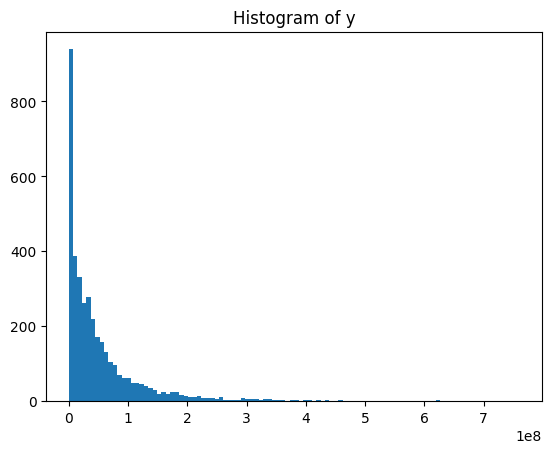

gross
218051260.0    3
8000000.0      3
47000000.0     3
177343675.0    3
5773519.0      3
              ..
10174663.0     1
1573712.0      1
6706368.0      1
155984.0       1
141614023.0    1
Name: count, Length: 3694, dtype: int64

In [4]:
X = movie_metadata.drop(columns=["gross"])
y = movie_metadata.gross

#seeing if y is normal, it is not normal. So we will need to transform it
plt.hist(y, bins='auto')
plt.title('Histogram of y')
plt.show()

#we are going to cut of the extreme values and then log transform the data
y.value_counts()


#6 Split your data into test, tune, and train. (80/10/10)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,random_state=49)

#7 Create the kfold object for cross validation.

In [6]:

kf =RepeatedKFold(n_splits=10,n_repeats =5, random_state=42)

#8 Create the scoring metric (several measures) you will use to evaluate your model and choose a hyperparamater to optimize.

In [7]:
param={
    "max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    #"min_samples_leaf":[1,2,3,4,5,6,7,8,9,10],
    #"min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    #"max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90] 
    #'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    #'ccp_alpha':[.001,.01,.1]
        }

scoring= ['neg_mean_squared_error','r2','neg_mean_absolute_error']



#9 Build the regression tree object. 

In [8]:
reg=DecisionTreeRegressor(random_state=30)
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')

#10 Fit the model to the training data.

In [9]:
model = search.fit(X_train, y_train)
best= model.best_estimator_
print(best)

DecisionTreeRegressor(max_depth=5, random_state=30)


#11 Explore the results of the model. Print the output of the grid search. What is the best parameter and score?

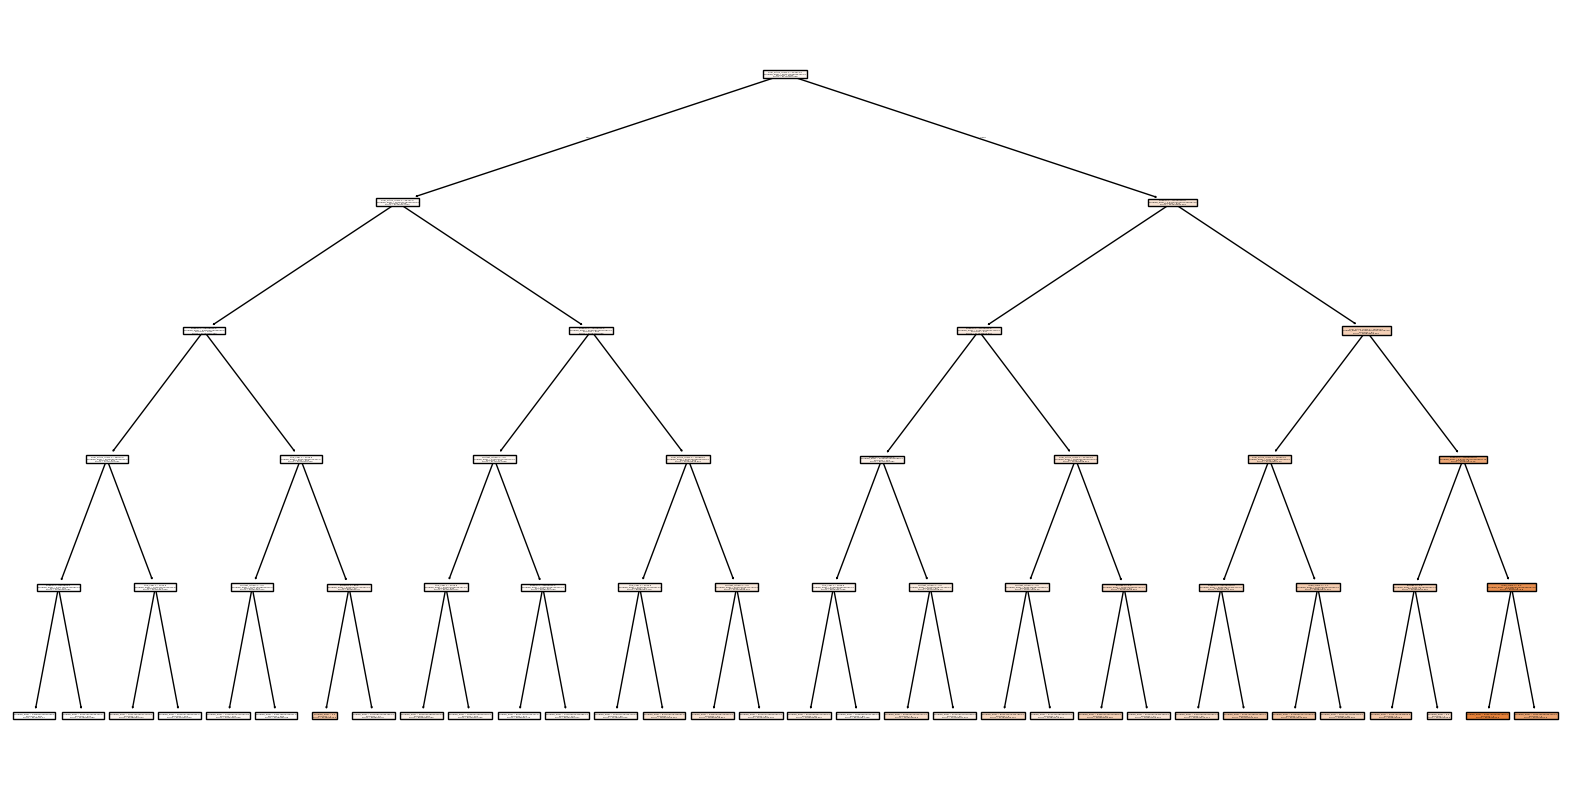

In [10]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(best, feature_names=X_train.columns, filled=True)
plt.show()

#12 Which variables appear to be contributing the most (variable importance) 

In [11]:

varimp=pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                 importance
num_voted_users    0.614361
budget             0.302048
content_rating     0.031583
title_year         0.022695
genres             0.012260
imdb_score         0.010547
duration           0.006506
color              0.000000
country            0.000000
plot_keywords      0.000000
language           0.000000


#13 Create a model object using the best model hyperparameter value from the trained regression tree. 

In [12]:

best_params = model.best_params_
print("Best hyperparameters:", best_params)
#The model preforms best with max depth, so can use that for the final model

reg=DecisionTreeRegressor(random_state=30)
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')

Best hyperparameters: {'max_depth': 5}


#14 Using the best model predict on the tune data and print out the results.

In [13]:
model2 = search.fit(X_tune, y_tune)
best2= model2.best_estimator_
print(best2)

DecisionTreeRegressor(max_depth=6, random_state=30)


#15 How does the model perform on the tune data as compared to the training data?
Preforms a little worse, but not by much. Max depth is 6 instead of 5 now. 


In [14]:
from sklearn.metrics import r2_score, mean_squared_error
y_train_pred = best.predict(X_train)
y_tune_pred = best.predict(X_tune)

r2_train = r2_score(y_train, y_train_pred)
r2_tune = r2_score(y_tune, y_tune_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_tune = np.sqrt(mean_squared_error(y_tune, y_tune_pred))

print("Train R2", r2_train)
print("Tune R2:", r2_tune)
print("Train RMSE:", rmse_train)
print("Tune RMSE:", rmse_tune)

Train R2 0.7255622515569128
Tune R2: 0.5703204325494715
Train RMSE: 36305149.01308438
Tune RMSE: 44261968.5311223


#16 What five movies are predicted to have the lowest gross revenue from the tune set? 

In [15]:
# Predict gross on the tune set
tune_preds = best.predict(X_tune)

# Get indices of lowest 5 predicted gross
lowest_indices = tune_preds.argsort()[:5]

# Retrieve the corresponding index from original DataFrame
tune_indices = X_tune.iloc[lowest_indices].index

# Use those indices to grab the original movie titles
bot_5_titles = movie_titles.loc[tune_indices, "movie_title"]

# Display
for i, title in enumerate(bot_5_titles, 1):
    print(f"{i}. {title}")



1. Limbo 
2. Two Can Play That Game 
3. The Legend of Drunken Master 
4. Cavite 
5. Fighting Tommy Riley 


#17 As a data scientist you are always looking to improve your results. What are some ideas you have to improve the model? Have you ask...WHAT IF?!

As a data scientist some ideas I had to improve my model were to remove the outliers in the data. The model is heavily skewed to the right, so removing the outliers would help to make the data more normally distributed. I would also apply a log transformation to the data. This will make it easier for the model to process. From here maybe a different hyper parameter would be better for the model. Or I could change the max depth of the model to include more. This will hopefully allow the model to learn more from the data. 


#18 Experiment using your what if ideas (two is fine). Did the model improve? If so, how much? If not, what did you learn? (You don't need to include all the "what if" code just speak to what you tried and what you learned).

In [16]:
#I am going to try and normalize the data, and then do the log transformation to see if that helps the model 
#finding the upper and lower bounds of the data
lower_bound = movie_metadata['gross'].quantile(0.01)
upper_bound = movie_metadata['gross'].quantile(0.99)

#removing the outliers through the bounds (IQR method)
filtered_df = movie_metadata[(movie_metadata['gross'] >= lower_bound) & (movie_metadata['gross'] <= upper_bound)].copy()
# Apply log transformation
filtered_df['gross_log'] = np.log1p(filtered_df['gross'])

#assigning the filtered data to the X and y variables
X2 = filtered_df.drop(columns=['gross', 'gross_log'])
y2 = filtered_df['gross_log']

#spliting the data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, train_size=0.70, random_state=21)
X_tune2, X_test2, y_tune2, y_tes2 = train_test_split(X_test2,y_test2,  train_size = 0.50,random_state=49)

#making the model
model3 = search.fit(X_train2, y_train2)
best= model3.best_estimator_
print(best)

#looking at accuracy
y_train_pred_log = best.predict(X_train2)
y_tune_pred_log = best.predict(X_tune2)

# Evaluate in log scale
r2_train = r2_score(y_train2, y_train_pred_log)
r2_tune = r2_score(y_tune2, y_tune_pred_log)

rmse_train_log = np.sqrt(mean_squared_error(y_train2, y_train_pred_log))
rmse_tune_log = np.sqrt(mean_squared_error(y_tune2, y_tune_pred_log))

print("Train R2:", r2_train)
print("Tune R2:", r2_tune)
print("Train RMSE (log scale):", rmse_train_log)
print("Tune RMSE (log scale):", rmse_tune_log)

#model 1 still preforms better than model 3, despite the log transformation and removal of the outliers. Therefore, I will use model 1 for the final model

DecisionTreeRegressor(max_depth=6, random_state=30)
Train R2: 0.6842094734614195
Tune R2: 0.5003461585534517
Train RMSE (log scale): 1.0942486377631184
Tune RMSE (log scale): 1.3504461476251102


#19 Use the best model to predict on the test data and print out the evaluation results.

In [17]:
model = search.fit(X_test, y_test)
best= model.best_estimator_
print(best)

#looking at accuracy
y_train_pred = best.predict(X_train)
y_test_pred = best.predict(X_test)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Train R2:", r2_train)
print("Test R2:", r2_test)
print("Train RMSE:", rmse_train)
print("Tune RMSE:", rmse_test)

DecisionTreeRegressor(max_depth=3, random_state=30)
Train R2: 0.4062719233918677
Test R2: 0.6243814360620846
Train RMSE: 53399856.89163645
Tune RMSE: 46649272.94455746


#20 Does the model perform well on the test data when compared to the training and tune data? Why or why not? 

Yes, the model performs well on the test data, with a higher R2 score (0.624) than on the training data (0.406). This suggests good generalization to new data. However, the lower training R2 indicates some underfitting, likely due to the shallow tree depth which was three. Overall, the model avoids overfitting and makes accurate predictions, but allowing more complexity could improve performance.

#21 Where are the errors occurring in your predictions? Are they systematic or random? In either case, what are the implications of this?

The errors that did occur in the model seem relatively systematic. Some variation is expected in any model, my model appears to underpredict the higher grossing movies. While at the same time overpredicting the lower grossing movies. Which could indicate that the model doesn't do well with the extreme values. This could be due to the skewed distribution of the gross revenue from movies. The implication of this error is that the model is able to predict the average or moderate movies well. However it is unable to predict the outliers as well, which could be a major issues because the model wants to predict very successful movies.


#22 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.

To start I learned what Regression Decision Trees should be used for, when predicting a continuous variable. In this case it was better to predict the gross revenue of the movies. Also how important it is to preprocess the data before using it as it can make your model much more accurate. I also learned how changing the hyperparameter of the model can help identify if the model is overfitting or underfitting. This can be seen in the train, tune, and test data sets. Ensuring that the model is the best it can be. Moving foward, the model could be used to predict the gross revenue of movies that have not been released. Based on budget and the number of votes it received. This could be helpful to decide how much more should be spent on marketing or if the movie should be released at all. However, as the model doesn't do well with extreme values this should be taken lighly and as a general idea. Doesnt ensure that the movie will be a blockbuster or a flop.